In [146]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [148]:
df = pd.read_csv("cleaned_data.csv")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,4,1,2,0,2143.0,1,0,2,5.0,8,261.0,1.0,-1.0,0.0,3,0
1,44.0,9,2,1,0,29.0,1,0,2,5.0,8,151.0,1.0,-1.0,0.0,3,0
2,33.0,2,1,1,0,2.0,1,1,2,5.0,8,76.0,1.0,-1.0,0.0,3,0
3,47.0,1,1,1,0,1506.0,1,0,2,5.0,8,92.0,1.0,-1.0,0.0,3,0
4,33.0,1,2,1,0,1.0,0,0,2,5.0,8,198.0,1.0,-1.0,0.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51.0,9,1,2,0,825.0,0,0,0,17.0,9,643.0,3.0,-1.0,0.0,3,1
45207,70.5,5,0,0,0,1729.0,0,0,0,17.0,9,456.0,2.0,-1.0,0.0,3,1
45208,70.5,5,1,1,0,3462.0,0,0,0,17.0,9,643.0,5.0,-1.0,0.0,2,1
45209,57.0,1,1,1,0,668.0,0,0,1,17.0,9,508.0,4.0,-1.0,0.0,3,0


## Task 3

Separate features & target

In [152]:
X = df.drop('y', axis=1)
y = df['y']

Train–Test Split

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

Train Decision Tree Model

In [158]:
dt_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced'
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=10, random_state=42)

Prediction

In [161]:
y_pred = dt_model.predict(X_test)

Accuracy

In [164]:
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.8397014100082941


## Task 4

Test the Model on Test Dataset

In [168]:
y_test_pred = dt_model.predict(X_test)

Compute Evaluation Metrics

1.Accuracy

In [172]:
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8397014100082941


2.Confusion Matrix

In [175]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[13735  2249]
 [  650  1451]]


3. Classification Report

In [178]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     15984
           1       0.39      0.69      0.50      2101

    accuracy                           0.84     18085
   macro avg       0.67      0.77      0.70     18085
weighted avg       0.89      0.84      0.86     18085



Check Overfitting / Underfitting

In [181]:
train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)

print(f"Train: {train_acc:.2f}, Test: {test_acc:.2f}")

if train_acc < 0.60:  
    print("Underfitting")
elif (train_acc - test_acc) > 0.05:
    print("Overfitting")
elif test_acc > train_acc:
    print("Data leakage or improper split")
else:
    print("Well-fitted model")

Train: 0.84, Test: 0.84
Well-fitted model


## TASK 5: Advanced Model Training

Train Multiple Models

In [232]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models_to_test = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()), 
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": Pipeline([
        ('scaler', StandardScaler()), 
        ('clf', SVC(random_state=42))
    ])
}

print("Models initialized successfully.")

Models initialized successfully.


Cross-Validation

In [234]:
cv_results = {}
cv_means = {}

print("Starting Cross-Validation (this may take a minute)...")

for name, model in models_to_test.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    cv_means[name] = scores.mean()
    print(f"{name}: Mean Accuracy = {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

results_df = pd.DataFrame({
    'Model': cv_means.keys(),
    'Mean Accuracy': cv_means.values()
}).sort_values(by='Mean Accuracy', ascending=False)

print("\nModel Rankings:")
print(results_df)

Starting Cross-Validation (this may take a minute)...
Logistic Regression: Mean Accuracy = 0.8881 (+/- 0.0074)
Decision Tree: Mean Accuracy = 0.8710 (+/- 0.0063)
Random Forest: Mean Accuracy = 0.9000 (+/- 0.0024)
SVM: Mean Accuracy = 0.8912 (+/- 0.0039)

Model Rankings:
                 Model  Mean Accuracy
2        Random Forest       0.900022
3                  SVM       0.891211
0  Logistic Regression       0.888115
1        Decision Tree       0.870972


Compare Models based on Validation Metrics

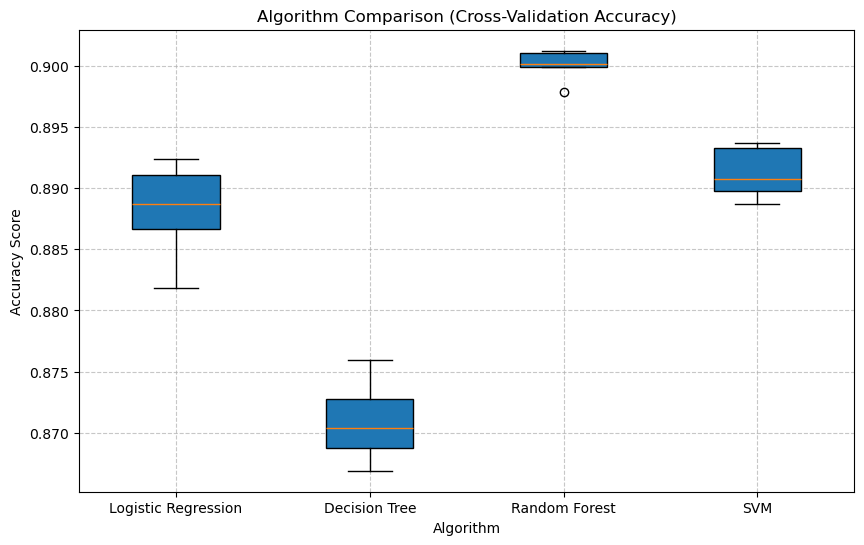

In [236]:
plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), tick_labels=cv_results.keys(), patch_artist=True)
plt.title('Algorithm Comparison (Cross-Validation Accuracy)')
plt.ylabel('Accuracy Score')
plt.xlabel('Algorithm')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Hyperparameter Tuning

In [237]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Starting Hyperparameter Tuning for Random Forest...")

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3, 
    n_jobs=-1, 
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
print("\nBest Parameters found:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Starting Hyperparameter Tuning for Random Forest...
Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best Parameters found: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.9032662390326625


Final Evaluation of Tuned Model

--- Final Tuned Random Forest Performance ---
Test Accuracy: 0.9010

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     15984
           1       0.61      0.40      0.49      2101

    accuracy                           0.90     18085
   macro avg       0.77      0.68      0.72     18085
weighted avg       0.89      0.90      0.89     18085



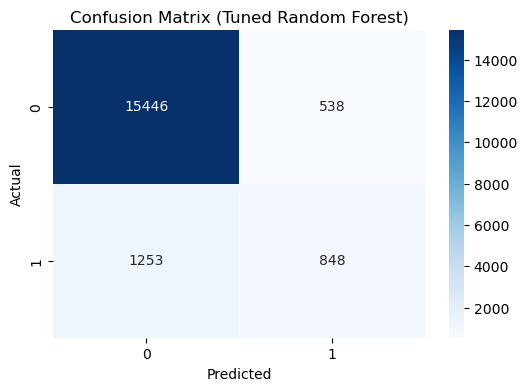

In [250]:
from sklearn.metrics import classification_report, confusion_matrix

y_tuned_pred = best_rf_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_tuned_pred)

print("--- Final Tuned Random Forest Performance ---")
print(f"Test Accuracy: {tuned_accuracy:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_tuned_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_tuned_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Task 6: Visualization of Metrics and Graphs.

Confusion Matrix

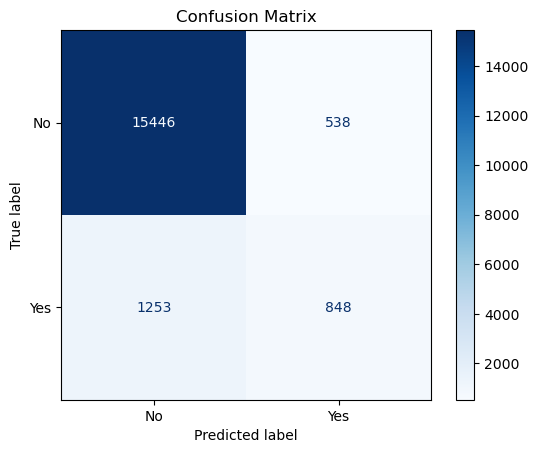

In [255]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    best_rf_model, 
    X_test, 
    y_test, 
    cmap='Blues',
    display_labels=['No', 'Yes']
)

plt.title("Confusion Matrix")
plt.grid(False) 
plt.show()

ROC Curve (AUC)

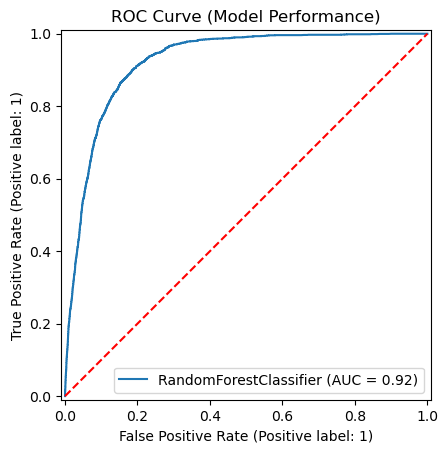

In [258]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_rf_model, X_test, y_test)

plt.title("ROC Curve (Model Performance)")
plt.plot([0, 1], [0, 1], 'r--') 
plt.show()